# 5 Machine Learning - Political

Because there are many missing values for 'political' feature in our dataset, I decided to focus on it seperately.

In [1]:
from sklearn.linear_model import LogisticRegression, LinearRegression, SGDRegressor
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from utils import load_user_like_matrix, plot_roc_curve, test_logreg_target

Let's load our data:

In [2]:
users = pd.read_csv('data/users_trimmed.csv', index_col=False)
users.drop('Unnamed: 0', inplace=True, axis='columns')

In [3]:
users

,userid,gender,age,political,ope,con,ext,agr,neu
0,c6a9a43058c8cc8398ca6e97324c0fae,0,47,NaN,-0.31,-0.57,-0.89,0.41,1.17
1,e557fd2902b857797cb8cec471f201a5,0,35,NaN,0.61,-0.12,-0.64,-1.01,-1.50
2,f9ed42fd1c0e0e1ecd2ba3fdb54ce6fa,1,29,0.0,-0.31,-0.94,-0.77,-1.76,1.05
3,eca69bfad8f4f2b193b2592248101b7f,1,28,0.0,-0.68,0.54,-0.52,-1.01,-0.51
4,1e4e4517e035a0d5f6dd5bfd1fe65890,0,35,NaN,-0.41,-0.86,-1.02,-0.18,0.30
...,...,...,...,...,...,...,...,...,...
19737,3995772c890538007229320216aec92f,1,23,NaN,-0.31,-1.97,-1.21,-1.09,1.79
19738,f9a122ccb0ae03e0e67a6024f46d38d9,1,26,1.0,1.26,0.17,1.11,0.12,0.18
19739,8a1c71c937b9a01c6983d86a4396a240,1,20,NaN,-0.04,0.69,0.17,0.82,0.80
19740,d0c8717c1584b4be1a0d28a5e0f25c70,1,35,0.0,1.63,-0.72,1.86,1.41,-1.01


In [4]:
users['political'].isna().sum()

14998

There are a few ways to handle missing data:
- I can input some values myself, e.g. based on frequency or 'k-nearest' method
- I can encode a 'missing' value as a value in itself
- but for simplicity I will only focus on Users that decided to share their political views

Loading User-Like matrix:

In [5]:
df = load_user_like_matrix()

Reducing it to 50 dimensions using SVD:

In [6]:
svd_50 = TruncatedSVD(n_components=50, random_state=42)

In [7]:
svd_50.fit(df)

TruncatedSVD(algorithm='randomized', n_components=50, n_iter=5, random_state=42,
             tol=0.0)

In [8]:
X_svd_50 = svd_50.transform(df)

In [9]:
X_svd_50 = pd.DataFrame(X_svd_50)

Combining it with Users dataframe to remove the samples with NaN values:

In [10]:
merged_svd_50 = pd.concat([users, X_svd_50], axis=1)

In [11]:
merged_svd_50

,userid,gender,age,political,ope,con,ext,agr,neu,0,...,40,41,42,43,44,45,46,47,48,49
0,c6a9a43058c8cc8398ca6e97324c0fae,0,47,NaN,-0.31,-0.57,-0.89,0.41,1.17,0.242033,...,-0.166992,0.086621,0.452880,-0.251522,0.112301,-0.134991,-0.022330,0.067848,0.028435,-0.188740
1,e557fd2902b857797cb8cec471f201a5,0,35,NaN,0.61,-0.12,-0.64,-1.01,-1.50,0.430053,...,-0.166240,-0.126951,0.206703,-0.675187,-0.208379,-0.279976,-0.483428,-0.049299,0.315360,0.122851
2,f9ed42fd1c0e0e1ecd2ba3fdb54ce6fa,1,29,0.0,-0.31,-0.94,-0.77,-1.76,1.05,0.720854,...,0.105962,-0.053665,0.308653,0.094177,0.132226,-0.520239,-0.247787,0.174664,0.228318,0.093811
3,eca69bfad8f4f2b193b2592248101b7f,1,28,0.0,-0.68,0.54,-0.52,-1.01,-0.51,1.285244,...,0.789653,-0.248334,0.613529,0.378949,-0.449087,-0.773445,-0.420456,-0.237375,-0.027646,-0.729595
4,1e4e4517e035a0d5f6dd5bfd1fe65890,0,35,NaN,-0.41,-0.86,-1.02,-0.18,0.30,0.387822,...,-0.255670,0.300201,0.129738,0.119602,-0.138349,0.100356,-0.036676,-0.004481,0.133341,0.278207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19737,3995772c890538007229320216aec92f,1,23,NaN,-0.31,-1.97,-1.21,-1.09,1.79,2.009041,...,0.231533,-0.412382,0.677956,0.212807,-0.553049,0.214805,-0.349175,-0.360545,0.261651,-0.438740
19738,f9a122ccb0ae03e0e67a6024f46d38d9,1,26,1.0,1.26,0.17,1.11,0.12,0.18,5.007482,...,1.006846,1.236978,-2.173863,2.181111,-0.631921,0.207862,0.497802,-0.142507,0.656912,0.001547
19739,8a1c71c937b9a01c6983d86a4396a240,1,20,NaN,-0.04,0.69,0.17,0.82,0.80,1.006331,...,0.791618,-0.041324,-0.109731,-0.187362,-0.042231,0.250531,0.312826,-0.116730,0.116504,-0.331054
19740,d0c8717c1584b4be1a0d28a5e0f25c70,1,35,0.0,1.63,-0.72,1.86,1.41,-1.01,0.933533,...,-0.247148,-0.051479,-0.183399,0.234328,0.168296,0.434699,0.331103,-0.202796,0.002396,0.008595


In [12]:
merged_svd_50 = merged_svd_50.dropna(how='any')

In [13]:
merged_svd_50

,userid,gender,age,political,ope,con,ext,agr,neu,0,...,40,41,42,43,44,45,46,47,48,49
2,f9ed42fd1c0e0e1ecd2ba3fdb54ce6fa,1,29,0.0,-0.31,-0.94,-0.77,-1.76,1.05,0.720854,...,0.105962,-0.053665,0.308653,0.094177,0.132226,-0.520239,-0.247787,0.174664,0.228318,0.093811
3,eca69bfad8f4f2b193b2592248101b7f,1,28,0.0,-0.68,0.54,-0.52,-1.01,-0.51,1.285244,...,0.789653,-0.248334,0.613529,0.378949,-0.449087,-0.773445,-0.420456,-0.237375,-0.027646,-0.729595
8,61a7d34e72501a85149c468a38a076f4,0,32,0.0,1.44,1.21,0.73,-1.26,0.11,0.975824,...,0.002610,0.506137,-0.129410,0.040827,-0.028999,-0.338141,0.078073,-0.021548,-0.354498,-0.990605
9,1a4c012c71f7e0864e98ba7e029b66d3,1,35,0.0,-1.33,-0.72,0.04,-0.51,-0.14,0.697555,...,0.087571,-0.053617,0.360669,-0.244456,-0.161791,-0.788280,-0.208119,-0.081966,-0.554945,-0.353295
10,7eb0c95dbec7f9e6f8d37e1456f8956c,1,35,0.0,0.52,1.50,1.79,-0.26,-0.45,1.550690,...,-0.050652,-0.382855,-0.069548,0.181247,-0.045937,-0.784985,-0.372504,0.100664,-0.055044,-0.339294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19731,eb64acdea3957c0e0b8e99d65b418d2f,0,26,0.0,0.24,1.43,0.54,0.74,-1.44,8.455098,...,0.408901,-0.646469,0.343023,-1.125712,-0.949263,0.352291,1.714115,-0.276977,-0.071565,-0.541063
19735,18d57c5da9bb008838e40f5dabf03f68,0,27,0.0,0.79,0.69,-1.39,-2.26,1.36,1.223925,...,0.337149,0.179868,-0.389601,0.074659,-0.091644,0.598191,-0.581226,-0.398855,-0.402785,-0.231474
19738,f9a122ccb0ae03e0e67a6024f46d38d9,1,26,1.0,1.26,0.17,1.11,0.12,0.18,5.007482,...,1.006846,1.236978,-2.173863,2.181111,-0.631921,0.207862,0.497802,-0.142507,0.656912,0.001547
19740,d0c8717c1584b4be1a0d28a5e0f25c70,1,35,0.0,1.63,-0.72,1.86,1.41,-1.01,0.933533,...,-0.247148,-0.051479,-0.183399,0.234328,0.168296,0.434699,0.331103,-0.202796,0.002396,0.008595


So we're down to 4744 observations out of 19742. Let's see if that's enough.

### Baseline SVD k = 50 predictions

In [14]:
X = merged_svd_50[range(50)]
y = merged_svd_50['political']

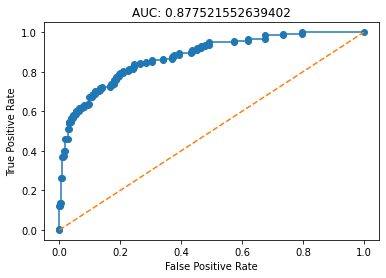

In [15]:
svd_50_result = test_logreg_target(X, y, 'political_svd_50_result')

In [16]:
svd_50_result

,name,political
0,political_svd_50_result,0.87


### SVD k = 300 - data preparation

Here I'm just repeating steps from above with k = 300:

In [17]:
svd_300 = TruncatedSVD(n_components=300, random_state=42)

In [18]:
svd_300.fit(df)

TruncatedSVD(algorithm='randomized', n_components=300, n_iter=5,
             random_state=42, tol=0.0)

In [19]:
X_svd_300 = svd_300.transform(df)

In [20]:
X_svd_300 = pd.DataFrame(X_svd_300)

In [21]:
merged_svd_300 = pd.concat([users, X_svd_300], axis=1)

In [22]:
merged_svd_300 

,userid,gender,age,political,ope,con,ext,agr,neu,0,...,290,291,292,293,294,295,296,297,298,299
0,c6a9a43058c8cc8398ca6e97324c0fae,0,47,NaN,-0.31,-0.57,-0.89,0.41,1.17,0.242033,...,0.047424,-0.025516,-0.081927,0.011065,-0.191094,0.019342,0.052222,-0.108164,0.182441,0.006117
1,e557fd2902b857797cb8cec471f201a5,0,35,NaN,0.61,-0.12,-0.64,-1.01,-1.50,0.430053,...,-0.061858,0.034890,-0.220163,0.091034,-0.074247,-0.040295,-0.065375,-0.102663,0.037818,0.078651
2,f9ed42fd1c0e0e1ecd2ba3fdb54ce6fa,1,29,0.0,-0.31,-0.94,-0.77,-1.76,1.05,0.720854,...,0.101942,0.008952,-0.134874,-0.292882,-0.011664,-0.026001,0.261361,0.140387,0.183501,-0.073208
3,eca69bfad8f4f2b193b2592248101b7f,1,28,0.0,-0.68,0.54,-0.52,-1.01,-0.51,1.285244,...,0.011178,-0.087219,-0.092511,0.172560,0.099986,0.291616,-0.264882,0.059287,-0.112089,0.253434
4,1e4e4517e035a0d5f6dd5bfd1fe65890,0,35,NaN,-0.41,-0.86,-1.02,-0.18,0.30,0.387822,...,-0.055704,-0.252958,-0.114877,-0.116586,0.143883,-0.062297,0.127642,-0.154913,-0.141743,-0.031031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19737,3995772c890538007229320216aec92f,1,23,NaN,-0.31,-1.97,-1.21,-1.09,1.79,2.009041,...,0.095502,0.079516,-0.057048,0.055956,-0.193610,-0.153960,-0.172865,0.251261,0.136017,0.045651
19738,f9a122ccb0ae03e0e67a6024f46d38d9,1,26,1.0,1.26,0.17,1.11,0.12,0.18,5.007482,...,0.375511,0.107886,-0.372912,-0.381818,0.264707,0.379178,0.184254,0.155772,0.061867,0.221340
19739,8a1c71c937b9a01c6983d86a4396a240,1,20,NaN,-0.04,0.69,0.17,0.82,0.80,1.006331,...,0.084316,-0.394051,-0.198283,0.030014,0.123879,-0.298602,0.016080,-0.091375,0.165340,-0.008526
19740,d0c8717c1584b4be1a0d28a5e0f25c70,1,35,0.0,1.63,-0.72,1.86,1.41,-1.01,0.933533,...,-0.162863,-0.101097,-0.073174,-0.108160,0.174375,0.008650,0.051833,-0.008466,0.044313,-0.009541


In [23]:
merged_svd_300 = merged_svd_300.dropna(how='any')

In [24]:
merged_svd_300 

,userid,gender,age,political,ope,con,ext,agr,neu,0,...,290,291,292,293,294,295,296,297,298,299
2,f9ed42fd1c0e0e1ecd2ba3fdb54ce6fa,1,29,0.0,-0.31,-0.94,-0.77,-1.76,1.05,0.720854,...,0.101942,0.008952,-0.134874,-0.292882,-0.011664,-0.026001,0.261361,0.140387,0.183501,-0.073208
3,eca69bfad8f4f2b193b2592248101b7f,1,28,0.0,-0.68,0.54,-0.52,-1.01,-0.51,1.285244,...,0.011178,-0.087219,-0.092511,0.172560,0.099986,0.291616,-0.264882,0.059287,-0.112089,0.253434
8,61a7d34e72501a85149c468a38a076f4,0,32,0.0,1.44,1.21,0.73,-1.26,0.11,0.975824,...,-0.359491,-0.287270,0.003204,-0.061994,0.097546,0.060128,0.057257,-0.116548,0.130745,0.036890
9,1a4c012c71f7e0864e98ba7e029b66d3,1,35,0.0,-1.33,-0.72,0.04,-0.51,-0.14,0.697555,...,0.154523,0.025337,-0.094645,0.092371,-0.059660,0.014519,-0.049464,-0.113222,-0.078915,-0.093563
10,7eb0c95dbec7f9e6f8d37e1456f8956c,1,35,0.0,0.52,1.50,1.79,-0.26,-0.45,1.550690,...,-0.041795,0.126656,0.046213,-0.324600,0.110327,0.021223,0.616283,-0.154674,-0.154655,-0.193500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19731,eb64acdea3957c0e0b8e99d65b418d2f,0,26,0.0,0.24,1.43,0.54,0.74,-1.44,8.455098,...,0.134002,0.016877,0.349566,0.185086,-0.062904,-0.506931,0.937187,-0.349243,0.576761,0.006578
19735,18d57c5da9bb008838e40f5dabf03f68,0,27,0.0,0.79,0.69,-1.39,-2.26,1.36,1.223925,...,0.291037,-0.028909,0.266530,-0.165673,-0.346144,0.201905,-0.062649,0.216128,0.271042,-0.346923
19738,f9a122ccb0ae03e0e67a6024f46d38d9,1,26,1.0,1.26,0.17,1.11,0.12,0.18,5.007482,...,0.375511,0.107886,-0.372912,-0.381818,0.264707,0.379178,0.184254,0.155772,0.061867,0.221340
19740,d0c8717c1584b4be1a0d28a5e0f25c70,1,35,0.0,1.63,-0.72,1.86,1.41,-1.01,0.933533,...,-0.162863,-0.101097,-0.073174,-0.108160,0.174375,0.008650,0.051833,-0.008466,0.044313,-0.009541


### SVD k = 300 predictions:

In [25]:
X = merged_svd_300[range(300)]
y = merged_svd_300['political']

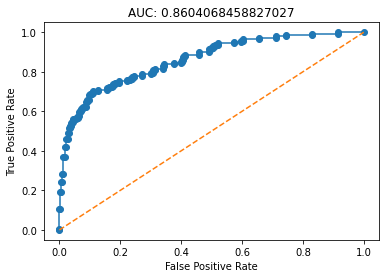

,name,political
0,political_svd_50_result,0.87


In [26]:
svd_300_result = test_logreg_target(X, y, 'political_svd_50_result')
svd_300_result

### Combined predictions - SVD k = 50 and psychographic data

In [27]:
X = merged_svd_50.drop(['political', 'userid'], axis='columns')
y = merged_svd_50['political']

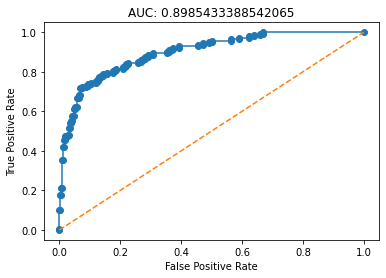

In [28]:
merged_svd_50_result = test_logreg_target(X, y, 'political_merged_svd_50_result')

In [29]:
merged_svd_50_result

,name,political
0,political_merged_svd_50_result,0.89


## Summary

Authors' score for Political views (AUC) was .88 for SVD k = 50. Mine was .87 for for both SVD k = 50 and k = 300. Adding psychographic features to the dataframe improved the result by 2% for k = 50.